In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Load datasets
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

# Display first 5 rows
print(train_df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

In [5]:
# =========================
# Import Libraries
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# =========================
# Remove unnecessary columns
# =========================

drop_cols = ['Unnamed: 0', 'trans_date_trans_time']

for col in drop_cols:

    if col in train_df.columns:
        train_df.drop(columns=col, inplace=True)

    if col in test_df.columns:
        test_df.drop(columns=col, inplace=True)


# =========================
# Encode categorical columns
# =========================

for column in train_df.columns:

    if train_df[column].dtype == 'object':

        le = LabelEncoder()

        combined = pd.concat([
            train_df[column].astype(str),
            test_df[column].astype(str)
        ])

        le.fit(combined)

        train_df[column] = le.transform(
            train_df[column].astype(str)
        )

        test_df[column] = le.transform(
            test_df[column].astype(str)
        )


# =========================
# Features and Target
# =========================

X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]


# =========================
# Convert to numeric
# =========================

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')


# =========================
# Replace inf values
# =========================

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)


# =========================
# Fill NaN values
# =========================

X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)


# =========================
# Feature Scaling
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# Verify NaN values
# =========================

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test :", np.isnan(X_test).sum())

print("\nPreprocessing Completed Successfully!")

NaN in X_train: 0
NaN in X_test : 0

Preprocessing Completed Successfully!


In [6]:
# =========================
# Remove rows where target has NaN
# =========================

# Train dataset
train_valid = ~y_train.isna()

X_train = X_train[train_valid]
y_train = y_train[train_valid]

# Test dataset
test_valid = ~y_test.isna()

X_test = X_test[test_valid]
y_test = y_test[test_valid]


# =========================
# Convert target to integer
# =========================

y_train = y_train.astype(int)
y_test = y_test.astype(int)


# =========================
# Final Check
# =========================

print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_test :", y_test.isna().sum())

print("\nTarget column cleaned successfully!")

NaN in y_train: 0
NaN in y_test : 0

Target column cleaned successfully!


In [7]:
# =========================
# Remove remaining NaN values from X
# =========================

# Convert arrays back to DataFrame temporarily
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Replace inf values again
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with column mean
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

# If any NaN still exists, fill with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Final verification
print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_test :", X_test.isna().sum().sum())

print("\nInput features cleaned successfully!")

NaN in X_train: 0
NaN in X_test : 0

Input features cleaned successfully!


In [8]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [9]:


# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression Results")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.9952998998973196
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    231749
           1       0.00      0.00      0.00      1012

    accuracy                           1.00    232761
   macro avg       0.50      0.50      0.50    232761
weighted avg       0.99      1.00      0.99    232761



In [10]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Decision Tree Results
Accuracy : 0.9955662675448207
Precision: 0.49015748031496065
Recall   : 0.49209486166007904
F1 Score : 0.4911242603550296

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    231749
           1       0.49      0.49      0.49      1012

    accuracy                           1.00    232761
   macro avg       0.74      0.74      0.74    232761
weighted avg       1.00      1.00      1.00    232761



In [11]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy : 0.996537220582486
Precision: 0.8527397260273972
Recall   : 0.24604743083003952
F1 Score : 0.38190184049079756

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    231749
           1       0.85      0.25      0.38      1012

    accuracy                           1.00    232761
   macro avg       0.92      0.62      0.69    232761
weighted avg       1.00      1.00      1.00    232761



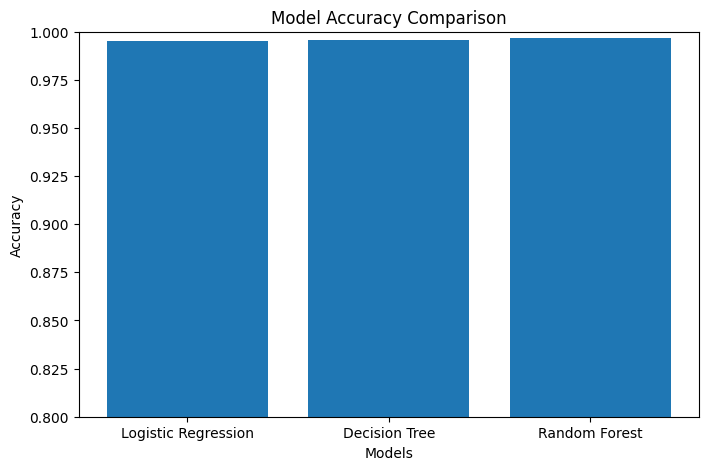

In [12]:
# Model Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [lr_accuracy, dt_accuracy, rf_accuracy]
f1_scores = [lr_f1, dt_f1, rf_f1]

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.ylim(0.8, 1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [17]:
# =========================
# Save original transaction numbers
# =========================

original_trans_num = test_df['trans_num'].copy()

In [19]:
# =========================
# Predict Using trans_num
# =========================

# Take transaction number from user
trans_id = input("Enter Transaction Number: ")

# Check if transaction exists
if trans_id in test_df['trans_num'].values:

    # Get matching row index
    row_index = test_df[
        test_df['trans_num'] == trans_id
    ].index[0]

    # Get transaction data
    transaction = X_test.iloc[row_index].reshape(1, -1)

    # Predict
    prediction = rf_model.predict(transaction)

    # Probability
    probability = rf_model.predict_proba(transaction)

    print("\nPrediction Result")

    if prediction[0] == 1:
        print("🚨 Fraudulent Transaction")
    else:
        print("✅ Legitimate Transaction")

    print("\nFraud Probability :", probability[0][1])
    print("Legitimate Probability :", probability[0][0])

else:
    print("Transaction Number Not Found")

Enter Transaction Number: f12cf52be2175703db789a4644c32f25
Transaction Number Not Found


In [20]:
print(original_trans_num.head(5))

0     82263
1     90596
2    360262
3     60048
4    158716
Name: trans_num, dtype: int64


In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("fraudTrain.csv")

# =========================
# Save original transaction numbers
# =========================
original_trans_num = df['trans_num'].astype(str)

# =========================
# Remove trans_num from encoding
# =========================
df_model = df.drop('trans_num', axis=1)

# =========================
# Encode only categorical columns
# =========================
label_encoders = {}

categorical_cols = df_model.select_dtypes(include=['object']).columns

for col in categorical_cols:

    # Skip target column if needed
    if col != 'is_fraud':

        le = LabelEncoder()

        df_model[col] = le.fit_transform(
            df_model[col].astype(str)
        )

        label_encoders[col] = le

# =========================
# Features and Target
# =========================
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, trans_train, trans_test = train_test_split(
    X,
    y,
    original_trans_num,
    test_size=0.2,
    random_state=42
)

In [30]:
print(len(rf_model.estimators_))

0


In [26]:
print(test_df['trans_num'].head(10))

0     82263
1     90596
2    360262
3     60048
4    158716
5    219297
6     41506
7    252036
8    204991
9    301927
Name: trans_num, dtype: int64


In [33]:
rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [37]:
# =====================================================
# CHECK WHETHER TRANSACTION IS FRAUD OR NOT
# =====================================================

# Reload original dataset
original_df = pd.read_csv("fraudTrain.csv")

# Get original transaction IDs
original_trans_num = original_df['trans_num'].astype(str)

# Reset indexes
original_trans_num = original_trans_num.reset_index(drop=True)
X = X.reset_index(drop=True)

# =====================================================
# USER INPUT
# =====================================================

trans_id = input("Enter Original Transaction Number: ").strip()

# Find matching transaction
matching_rows = original_trans_num[
    original_trans_num == trans_id
]

# If transaction exists
if not matching_rows.empty:

    # Get row index
    row_index = matching_rows.index[0]

    # Get transaction data
    transaction = X.iloc[[row_index]]

    # Predict
    prediction = rf_model.predict(transaction)[0]

    print("\n=========================")
    print("Prediction Result")
    print("=========================")

    # Fraud or Not
    if prediction == 1:
        print("🚨 Fraud Transaction")
    else:
        print("✅ Legal Transaction")

else:
    print("❌ Transaction Number Not Found")

Enter Original Transaction Number: d57648a57d97af8e9192e4f9ae909e18

Prediction Result
🚨 Fraud Transaction


In [38]:
# =====================================================
# CHECK WHETHER TRANSACTION IS FRAUD OR NOT
# =====================================================

# Reload original dataset
original_df = pd.read_csv("fraudTrain.csv")

# Get original transaction IDs
original_trans_num = original_df['trans_num'].astype(str)

# Reset indexes
original_trans_num = original_trans_num.reset_index(drop=True)
X = X.reset_index(drop=True)

# =====================================================
# USER INPUT
# =====================================================

trans_id = input("Enter Original Transaction Number: ").strip()

# Find matching transaction
matching_rows = original_trans_num[
    original_trans_num == trans_id
]

# If transaction exists
if not matching_rows.empty:

    # Get row index
    row_index = matching_rows.index[0]

    # Get transaction data
    transaction = X.iloc[[row_index]]

    # Predict
    prediction = rf_model.predict(transaction)[0]

    print("\n=========================")
    print("Prediction Result")
    print("=========================")

    # Fraud or Not
    if prediction == 1:
        print("🚨 Fraud Transaction")
    else:
        print("✅ Legal Transaction")

else:
    print("❌ Transaction Number Not Found")

Enter Original Transaction Number: 413636e759663f264aae1819a4d4f231

Prediction Result
✅ Legal Transaction
